In [1]:

from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
from google.colab import files
uploaded = files.upload()


Saving Dataset .csv to Dataset .csv


In [3]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully! ")
data = pd.read_csv('Dataset .csv')
print(f"\n Dataset loaded!")
print(f"Total restaurants: {len(data)}")
print(f"Total columns: {len(data.columns)}")
print("\nFirst 3 restaurants:")
data.head(3)

Libraries imported successfully! 

 Dataset loaded!
Total restaurants: 9551
Total columns: 21

First 3 restaurants:


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270


TASK 1 - Restaurant Ratings Analysis

Ratings Count:
Aggregate rating
0.0    2148
3.2     522
3.1     519
3.4     498
3.3     483
3.5     480
3.0     468
3.6     458
3.7     427
3.8     400
2.9     381
3.9     335
2.8     315
4.1     274
4.0     266
2.7     250
4.2     221
2.6     191
4.3     174
4.4     144
2.5     110
4.5      95
2.4      87
4.6      78
4.9      61
2.3      47
4.7      42
2.2      27
4.8      25
2.1      15
2.0       7
1.9       2
1.8       1
Name: count, dtype: int64

Rating Group Count:
Rating_Group
3-4    4388
2-3    1891
4-5    1114
1-2      10
0-1       0
Name: count, dtype: int64

Average Votes: 156.909747670401


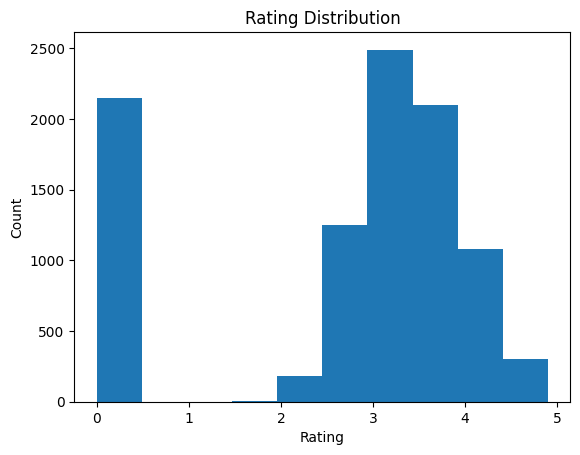

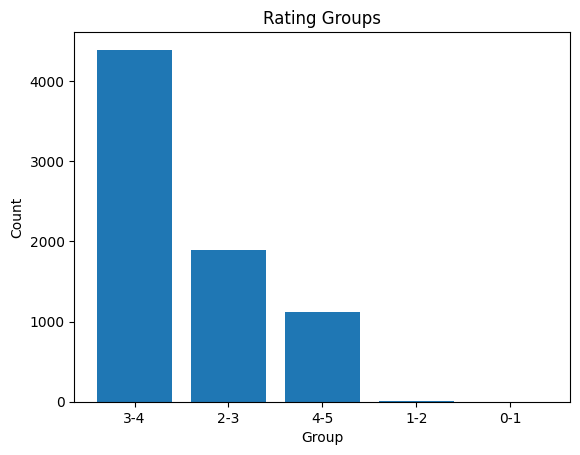

In [12]:

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Dataset.csv")

print("TASK 1 - Restaurant Ratings Analysis")

# 1. Rating count
rating_count = df["Aggregate rating"].value_counts()
print("\nRatings Count:")
print(rating_count)

# 2. Create rating groups
df["Rating_Group"] = pd.cut(df["Aggregate rating"],bins=[0,1,2,3,4,5],labels=["0-1","1-2","2-3","3-4","4-5"])
group_count = df["Rating_Group"].value_counts()
print("\nRating Group Count:")
print(group_count)

# 3. Average votes
average_votes = df["Votes"].mean()
print("\nAverage Votes:", average_votes)

# 4. Histogram
plt.hist(df["Aggregate rating"])
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# 5. Bar graph
plt.bar(group_count.index.astype(str), group_count.values)
plt.title("Rating Groups")
plt.xlabel("Group")
plt.ylabel("Count")
plt.savefig("level2_task1_ratings.png")
plt.show()

Top Cuisine Combinations:
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


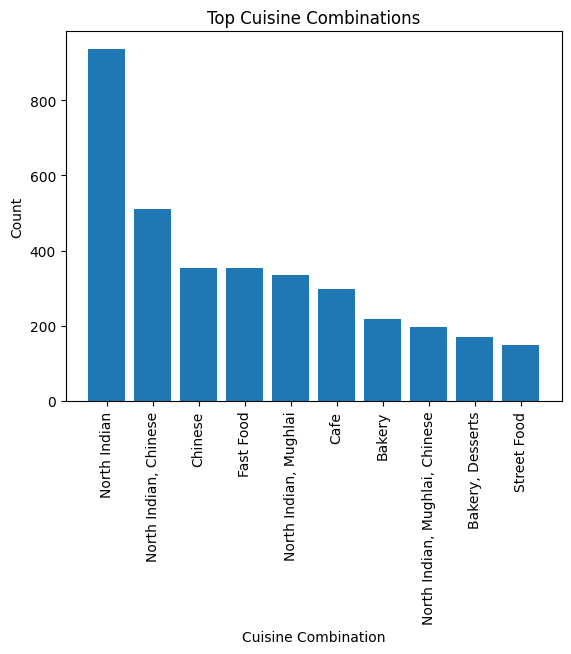


Cuisine Combinations with Highest Ratings:
Cuisines
Burger, Bar Food, Steak            4.9
American, Burger, Grill            4.9
American, Caribbean, Seafood       4.9
American, Coffee and Tea           4.9
Mexican, American, Healthy Food    4.9
Italian, Bakery, Continental       4.9
BBQ, Breakfast, Southern           4.9
European, German                   4.9
Hawaiian, Seafood                  4.9
Sunda, Indonesian                  4.9
Name: Aggregate rating, dtype: float64


<Figure size 640x480 with 0 Axes>

In [13]:
# Most common cuisine combinations
combo = df["Cuisines"].value_counts().head(10)

print("Top Cuisine Combinations:")
print(combo)

# Graph
plt.bar(combo.index, combo.values)
plt.xticks(rotation=90)
plt.title("Top Cuisine Combinations")
plt.xlabel("Cuisine Combination")
plt.ylabel("Count")
plt.show()

# Average rating for top combinations
avg_rating_combo = df.groupby("Cuisines")["Aggregate rating"].mean().sort_values(ascending=False).head(10)

print("\nCuisine Combinations with Highest Ratings:")
print(avg_rating_combo)
plt.savefig("level2_task2_cuisine_combinations.png")

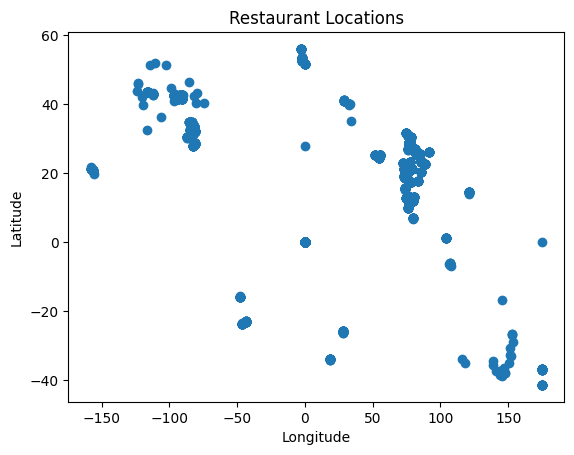

In [14]:
plt.scatter(df["Longitude"], df["Latitude"])
plt.title("Restaurant Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.savefig("level2_task3_geographic_analysis.png")
plt.show()


Restaurant Chains:
Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

Average Rating of Chains:
Restaurant Name
10 Downing Street            4.000000
221 B Baker Street           3.366667
34 Parkstreet Lane           3.050000
34, Chowringhee Lane         2.791667
4700BC Popcorn               3.500000
6 Pack Momos                 1.400000
A Piece of Paris             3.750000
AB's - Absolute Barbecues    4.825000
AB's Absolute Barbecues      4.850000
Aap Ki Khatir                0.000000
Name: Aggregate rating, dtype: float64


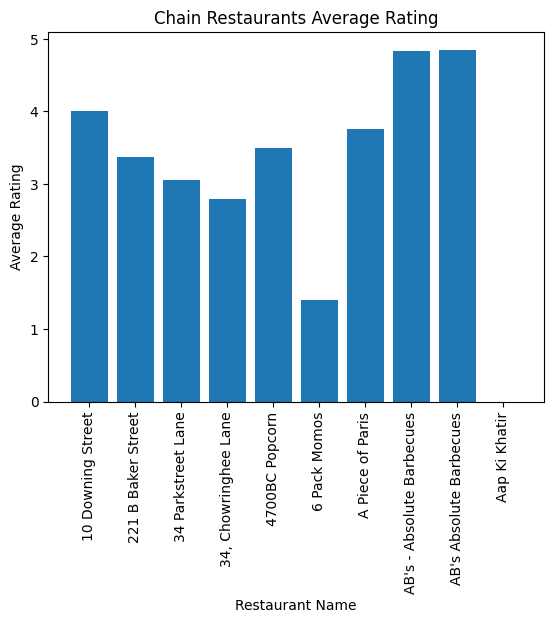

In [15]:
# Count restaurant names
name_count = df["Restaurant Name"].value_counts()

# Chains = names appearing more than once
chains = name_count[name_count > 1]

print("Restaurant Chains:")
print(chains.head(10))

# Average rating of chains
chain_ratings = df[df["Restaurant Name"].isin(chains.index)]
avg_chain_rating = chain_ratings.groupby("Restaurant Name")["Aggregate rating"].mean().head(10)

print("\nAverage Rating of Chains:")
print(avg_chain_rating)

# Graph
plt.bar(avg_chain_rating.index, avg_chain_rating.values)
plt.xticks(rotation=90)
plt.title("Chain Restaurants Average Rating")
plt.xlabel("Restaurant Name")
plt.ylabel("Average Rating")
plt.savefig("level2_task4_restaurant_chains.png")
plt.show()

In [16]:
from google.colab import files

# Download each Level-2 chart
files.download("level2_task1_ratings.png")
files.download("level2_task2_cuisine_combinations.png")
files.download("level2_task3_geographic_analysis.png")
files.download("level2_task4_restaurant_chains.png")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>